<center><h3>TP2</h3></center> The aim of this second practical lab session is to study the main algorithms which can be applied on graphs for graph
traversal, shortest paths finding, or minimum spanning tree computation, by using the NetworkX library.

In [108]:
import networkx as nx
import matplotlib.pyplot as plt

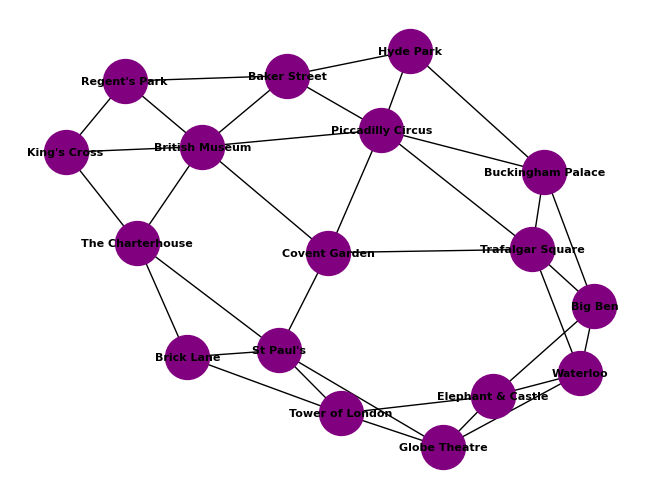

In [109]:
G = nx.read_graphml('ticket_to_ride_board_london.graphml')
nx.draw(G, with_labels=True, node_size=1000, node_color="purple", font_size=8, font_weight="bold")

1. How do you transform the graph of ”Ticket to ride” into a simple graph ? Apply this operation to transform it into a simple graph. From now on, we will refer to this transformed graph for the ”Ticket to ride” network.

In [110]:
print(type(G))
# C'est un graphe simple non orienté donc pas besoin de le convertir en graphe simple.
G_simple = nx.Graph(G)
print(type(G_simple))

<class 'networkx.classes.graph.Graph'>
<class 'networkx.classes.graph.Graph'>


2. Apply Depth First Search (DFS) graph traversal algorithm on the ”Ticket to ride” graph, starting from the ”British Museum” node. Do the same now starting from the ”Globe Theatre” node.

In [111]:
print(f"Les noeuds du graphe sont : {G.nodes()}\nle nombre de noeuds est : {G.number_of_nodes()}")
print(f"Les arêtes du graphe sont : {G.edges()}\nle nombre d'arêtes est : {G.number_of_edges()}")


Les noeuds du graphe sont : ["Regent's Park", "King's Cross", 'Baker Street', 'British Museum', 'Piccadilly Circus', 'Hyde Park', 'Buckingham Palace', 'Covent Garden', 'Trafalgar Square', 'Big Ben', 'Waterloo', 'Globe Theatre', "St Paul's", 'The Charterhouse', 'Brick Lane', 'Tower of London', 'Elephant & Castle']
le nombre de noeuds est : 17
Les arêtes du graphe sont : [("Regent's Park", 'Baker Street'), ("Regent's Park", "King's Cross"), ("Regent's Park", 'British Museum'), ("King's Cross", 'The Charterhouse'), ("King's Cross", 'British Museum'), ('Baker Street', 'British Museum'), ('Baker Street', 'Piccadilly Circus'), ('Baker Street', 'Hyde Park'), ('British Museum', 'The Charterhouse'), ('British Museum', 'Covent Garden'), ('British Museum', 'Piccadilly Circus'), ('Piccadilly Circus', 'Hyde Park'), ('Piccadilly Circus', 'Buckingham Palace'), ('Piccadilly Circus', 'Trafalgar Square'), ('Piccadilly Circus', 'Covent Garden'), ('Hyde Park', 'Buckingham Palace'), ('Buckingham Palace', '

In [112]:
dfs_british_museum = list(nx.dfs_preorder_nodes(G, source="British Museum"))
print("DFS à partir du noeud 'British Museum':", dfs_british_museum)

dfs_globe_theatre = list(nx.dfs_preorder_nodes(G, source="Globe Theatre"))
print("DFS à partir du noeud 'Globe Theatre':", dfs_globe_theatre)


DFS à partir du noeud 'British Museum': ['British Museum', "Regent's Park", 'Baker Street', 'Piccadilly Circus', 'Hyde Park', 'Buckingham Palace', 'Trafalgar Square', 'Covent Garden', "St Paul's", 'Globe Theatre', 'Waterloo', 'Big Ben', 'Elephant & Castle', 'Tower of London', 'Brick Lane', 'The Charterhouse', "King's Cross"]
DFS à partir du noeud 'Globe Theatre': ['Globe Theatre', 'Waterloo', 'Trafalgar Square', 'Piccadilly Circus', 'Baker Street', "Regent's Park", "King's Cross", 'The Charterhouse', 'British Museum', 'Covent Garden', "St Paul's", 'Tower of London', 'Brick Lane', 'Elephant & Castle', 'Big Ben', 'Buckingham Palace', 'Hyde Park']


In [113]:
def my_dfs(G, v):
    Stack = []
    discovered = set()
    result= []
    Stack.append(v)
    while len(Stack) > 0:
        v = Stack.pop()
        if v not in discovered:
            discovered.add(v)
            result.append(v)
            neighbors = list(G.neighbors(v))
            for neighbor in neighbors:
                if neighbor not in discovered:
                    Stack.append(neighbor)
    return result

In [114]:
result = my_dfs(G, "British Museum")
print(f"resutat final: {result}")

resutat final: ['British Museum', 'Piccadilly Circus', 'Covent Garden', 'Trafalgar Square', 'Waterloo', 'Elephant & Castle', 'Tower of London', 'Brick Lane', 'The Charterhouse', "St Paul's", 'Globe Theatre', "King's Cross", "Regent's Park", 'Baker Street', 'Hyde Park', 'Buckingham Palace', 'Big Ben']


In [115]:
result = my_dfs(G, "Globe Theatre")
print(f"resutat final: {result}")

resutat final: ['Globe Theatre', 'Tower of London', 'Elephant & Castle', 'Waterloo', 'Big Ben', 'Trafalgar Square', 'Covent Garden', "St Paul's", 'Brick Lane', 'The Charterhouse', 'British Museum', 'Piccadilly Circus', 'Buckingham Palace', 'Hyde Park', 'Baker Street', "Regent's Park", "King's Cross"]


3. Determine the shortest path between the nodes ”Seattle” and ”Santo Domingo” in the ”Pandemic” graph. Check the result by applying Dijkstra’s algorithm by hand.

In [116]:
G_poids = list(G.edges(data=True))
G_poids

[("Regent's Park", 'Baker Street', {'weight': 2, 'color': 'blue'}),
 ("Regent's Park", "King's Cross", {'weight': 3, 'color': 'green'}),
 ("Regent's Park", 'British Museum', {'weight': 3, 'color': 'yellow'}),
 ("King's Cross", 'The Charterhouse', {'weight': 3, 'color': 'pink'}),
 ("King's Cross", 'British Museum', {'weight': 2, 'color': 'black'}),
 ('Baker Street', 'British Museum', {'weight': 4, 'color': 'orange'}),
 ('Baker Street', 'Piccadilly Circus', {'weight': 4, 'color': 'gray'}),
 ('Baker Street', 'Hyde Park', {'weight': 4, 'color': 'black'}),
 ('British Museum', 'The Charterhouse', {'weight': 4, 'color': 'blue'}),
 ('British Museum', 'Covent Garden', {'weight': 1, 'color': 'gray'}),
 ('British Museum', 'Piccadilly Circus', {'weight': 2, 'color': 'gray'}),
 ('Piccadilly Circus', 'Hyde Park', {'weight': 2, 'color': 'gray'}),
 ('Piccadilly Circus', 'Buckingham Palace', {'weight': 2, 'color': 'pink'}),
 ('Piccadilly Circus', 'Trafalgar Square', {'weight': 1, 'color': 'orange'}),
 

In [152]:
import heapq

def my_dijkstra(G, source):
    distances = {node: float('inf') for node in G.nodes()}
    previous = {node: None for node in G.nodes()}
    distances[source] = 0
    priority_queue = [(0, source)]
    while priority_queue:
        current_dist, u = heapq.heappop(priority_queue)
        if current_dist > distances[u]:
            continue
        for v in G.neighbors(u):
            weight = G[u][v].get('weight', 1)
            alt = distances[u] + weight
            
            if alt < distances[v]:
                distances[v] = alt
                previous[v] = u
                heapq.heappush(priority_queue, (alt, v))
                
    return distances, previous

def get_path_from_previous(previous, source, target):
    path = []
    current_node = target
    while current_node is not None:
        path.append(current_node)
        if current_node == source:
            break
        current_node = previous[current_node]
    if path[-1] != source:
        return []
    return path[::-1]

In [157]:
distances, previous = my_dijkstra(G, "British Museum")
result = get_path_from_previous(previous, "British Museum", "Waterloo")
result, distances

(['British Museum', 'Covent Garden', 'Trafalgar Square', 'Waterloo'],
 {"Regent's Park": 3,
  "King's Cross": 2,
  'Baker Street': 4,
  'British Museum': 0,
  'Piccadilly Circus': 2,
  'Hyde Park': 4,
  'Buckingham Palace': 4,
  'Covent Garden': 1,
  'Trafalgar Square': 2,
  'Big Ben': 3,
  'Waterloo': 4,
  'Globe Theatre': 5,
  "St Paul's": 4,
  'The Charterhouse': 4,
  'Brick Lane': 7,
  'Tower of London': 7,
  'Elephant & Castle': 6})

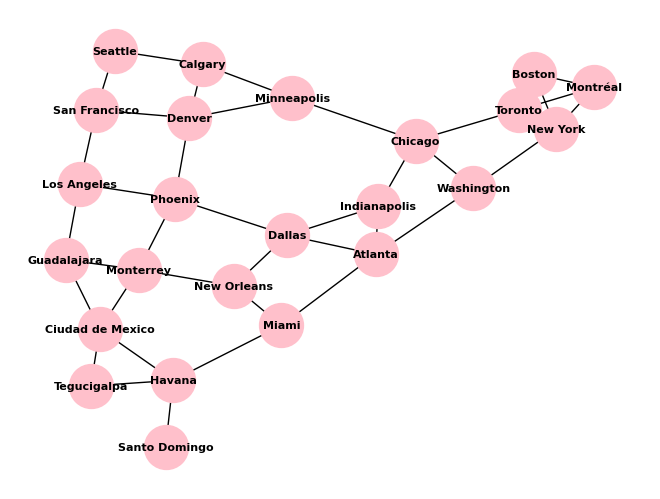

In [159]:
P = nx.read_graphml('pandemic_board_us.graphml')
nx.draw(P, with_labels=True, node_size=1000, node_color="pink", font_size=8, font_weight="bold")

In [163]:
for u,v in P.edges():
    P[u][v]["weight"] = 1

In [164]:
P["Phoenix"]["Dallas"].get("weight")

1

In [172]:
distances, previous = my_dijkstra(P, "Seattle")
result = get_path_from_previous(previous, "Seattle",  "Santo Domingo")
result

['Seattle',
 'San Francisco',
 'Los Angeles',
 'Guadalajara',
 'Ciudad de Mexico',
 'Havana',
 'Santo Domingo']

4. Apply the appropriate NetworkX function to determine the minimum-weight spanning tree of the two graphs. For each graph, is there a single minimum-weight spanning tree ?

Minimum-weight spanning tree of Ticket to Ride graph has edges: [("Regent's Park", 'Baker Street', {'weight': 2, 'color': 'blue'}), ("Regent's Park", "King's Cross", {'weight': 3, 'color': 'green'}), ("King's Cross", 'British Museum', {'weight': 2, 'color': 'black'}), ('British Museum', 'Covent Garden', {'weight': 1, 'color': 'gray'}), ('Piccadilly Circus', 'Trafalgar Square', {'weight': 1, 'color': 'orange'}), ('Piccadilly Circus', 'Covent Garden', {'weight': 1, 'color': 'yellow'}), ('Piccadilly Circus', 'Hyde Park', {'weight': 2, 'color': 'gray'}), ('Hyde Park', 'Buckingham Palace', {'weight': 1, 'color': 'orange'}), ('Trafalgar Square', 'Big Ben', {'weight': 1, 'color': 'gray'}), ('Trafalgar Square', 'Waterloo', {'weight': 2, 'color': 'gray'}), ('Waterloo', 'Globe Theatre', {'weight': 2, 'color': 'pink'}), ('Waterloo', 'Elephant & Castle', {'weight': 2, 'color': 'orange'}), ('Globe Theatre', "St Paul's", {'weight': 1, 'color': 'gray'}), ('Globe Theatre', 'Tower of London', {'weight'

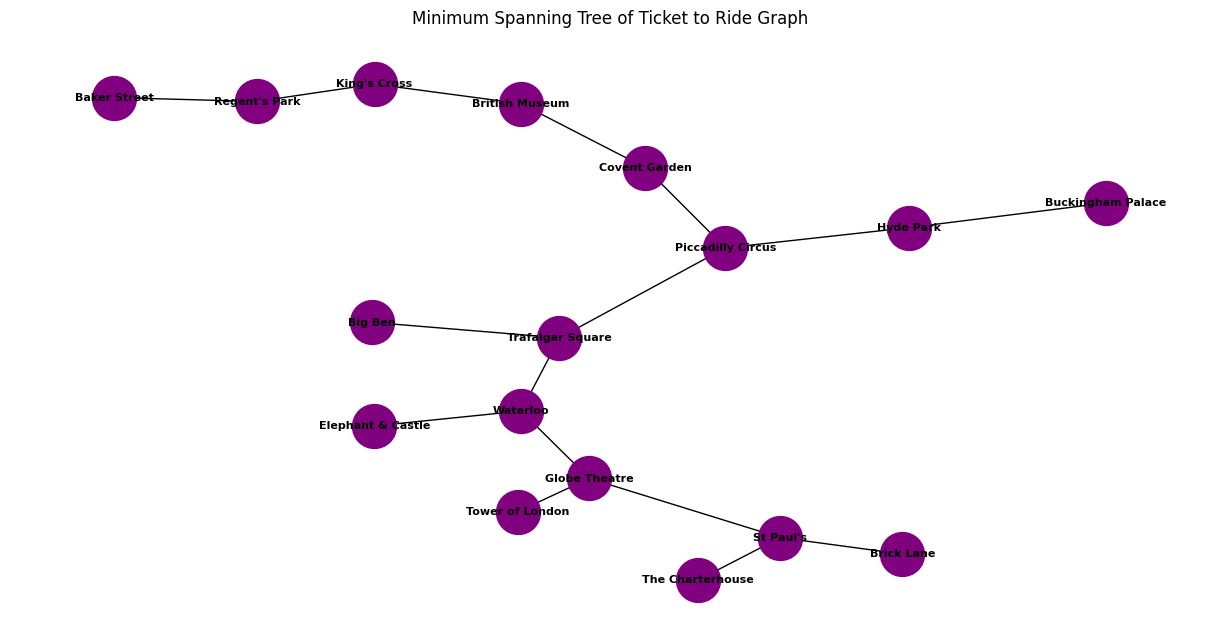

In [173]:
mst_G = nx.minimum_spanning_tree(G)
print("Minimum-weight spanning tree of Ticket to Ride graph has edges:", mst_G.edges(data=True))
plt.figure(figsize=(12, 6))
pos_G = nx.spring_layout(mst_G, seed=42)
nx.draw(mst_G, pos=pos_G, with_labels=True, node_size=1000, node_color="purple", font_size=8, font_weight="bold")
plt.title("Minimum Spanning Tree of Ticket to Ride Graph")
plt.show()

Minimum-weight spanning tree of Pandemic graph has edges: [('Calgary', 'Seattle', {'color': 'black', 'weight': 1}), ('Calgary', 'Denver', {'color': 'black', 'weight': 1}), ('Calgary', 'Minneapolis', {'color': 'black', 'weight': 1}), ('Seattle', 'San Francisco', {'color': 'black', 'weight': 1}), ('San Francisco', 'Los Angeles', {'color': 'black', 'weight': 1}), ('Denver', 'Phoenix', {'color': 'black', 'weight': 1}), ('Minneapolis', 'Chicago', {'color': 'black', 'weight': 1}), ('Los Angeles', 'Guadalajara', {'color': 'black', 'weight': 1}), ('Phoenix', 'Dallas', {'color': 'black', 'weight': 1}), ('Phoenix', 'Monterrey', {'color': 'black', 'weight': 1}), ('Dallas', 'Atlanta', {'color': 'black', 'weight': 1}), ('Dallas', 'Indianapolis', {'color': 'black', 'weight': 1}), ('Dallas', 'New Orleans', {'color': 'black', 'weight': 1}), ('Chicago', 'Washington', {'color': 'black', 'weight': 1}), ('Chicago', 'Toronto', {'color': 'black', 'weight': 1}), ('Toronto', 'Montréal', {'color': 'black', 'we

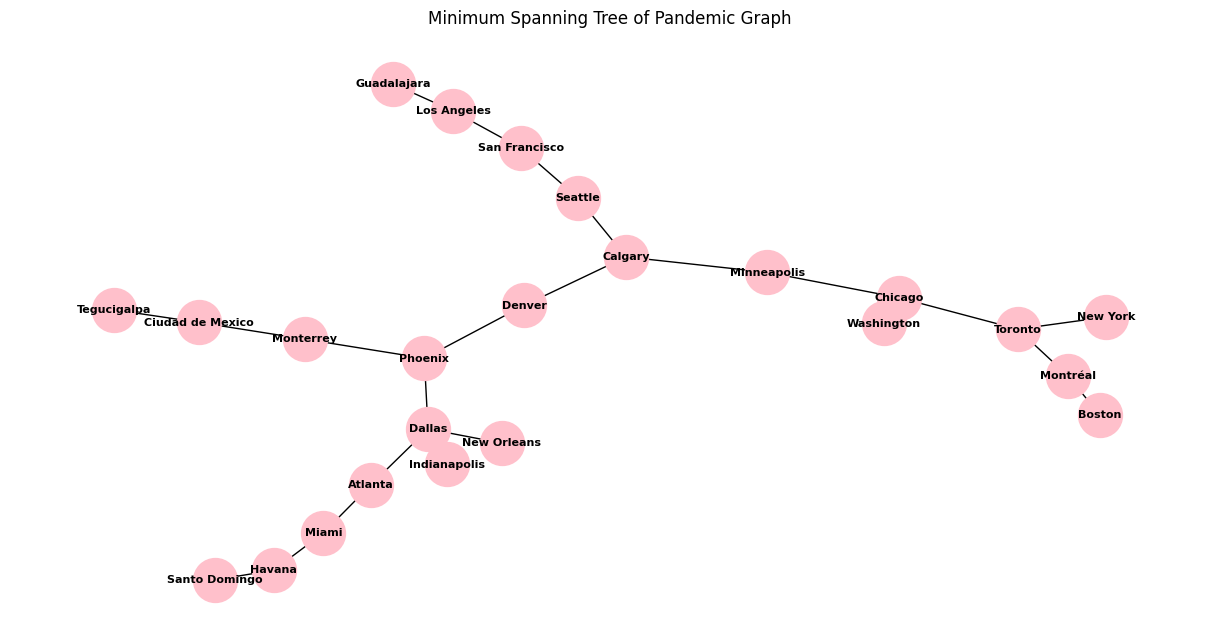

In [176]:
mst_P = nx.minimum_spanning_tree(P)
print("Minimum-weight spanning tree of Pandemic graph has edges:", mst_P.edges(data=True))
plt.figure(figsize=(12, 6))
pos_P = nx.spring_layout(mst_P, seed=42)
nx.draw(mst_P, pos=pos_P, with_labels=True, node_size=1000, node_color="pink", font_size=8, font_weight="bold")
plt.title("Minimum Spanning Tree of Pandemic Graph")
plt.show()


In [177]:
# Pour le graphe pandemic, il y'a N-1 Minimum spanning tree car tous les poids des arêtes sont = 1 sur chaque edge.
# de ce fait n'importe quel arbre couvrant sera de poids minimum

### Optionnel

J'ai codé et DFS et dijkstra en haut